In [8]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load the built-in NYC Taxi dataset
df_taxi = sns.load_dataset('taxis')

print("Dataset Loaded Successfully!")
df_taxi.head()

Dataset Loaded Successfully!


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [9]:
# 1. Convert pickup and dropoff to datetime objects
df_taxi['pickup'] = pd.to_datetime(df_taxi['pickup'])
df_taxi['dropoff'] = pd.to_datetime(df_taxi['dropoff'])

# 2. Drop rows with missing values (like missing 'borough' data)
df_taxi = df_taxi.dropna()

# 3. Add a 'hour' column to see when the most money is made
df_taxi['hour'] = df_taxi['pickup'].dt.hour

print("Data Cleaned! Ready for Analysis.")

Data Cleaned! Ready for Analysis.


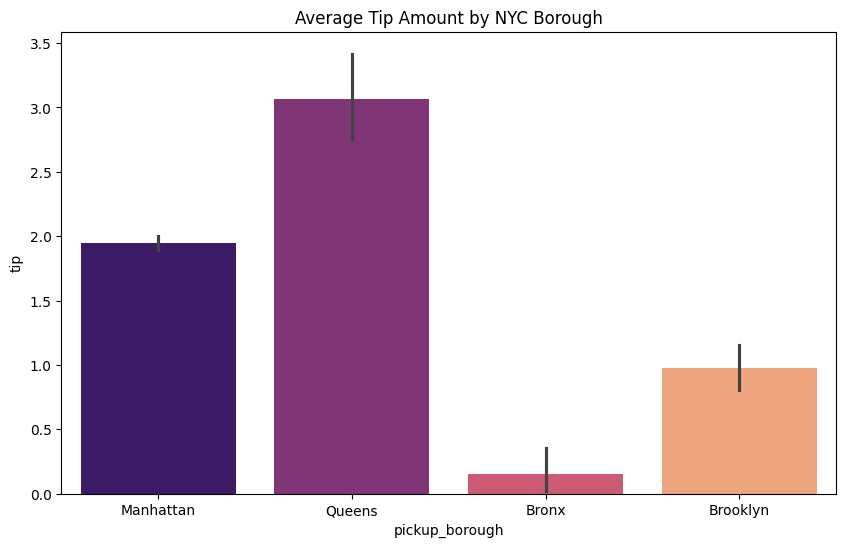

In [10]:
plt.figure(figsize=(10, 6))
# We added hue='pickup_borough' and legend=False to make the warning go away
sns.barplot(x='pickup_borough', y='tip', data=df_taxi, hue='pickup_borough', palette='magma', legend=False)
plt.title('Average Tip Amount by NYC Borough')
plt.show()

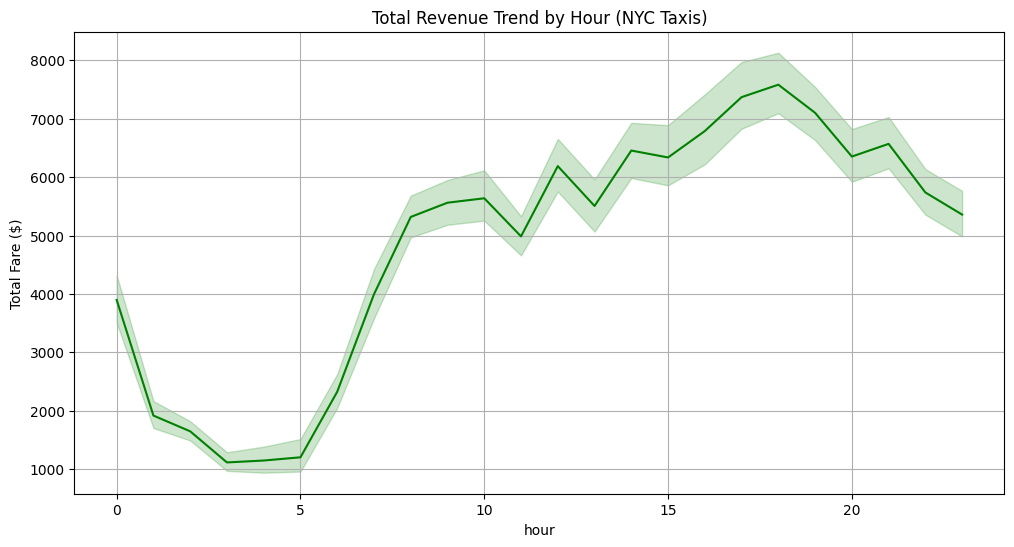

In [11]:
plt.figure(figsize=(12, 6))
# Lineplots don't usually trigger that warning, so this stays simple
sns.lineplot(x='hour', y='total', data=df_taxi, estimator='sum', color='green')
plt.title('Total Revenue Trend by Hour (NYC Taxis)')
plt.ylabel('Total Fare ($)')
plt.grid(True)
plt.show()